# Public Transportation Demand Forecasting
### Forecasting passenger arrivals using Time-Series models (STL+SARIMA, ETS, Regression)

**Author:** Shivangini Aggarwal | ISB AMPBA Co'26

**Tools:** Python, Pandas, Statsmodels, Scikit-learn, Matplotlib

**Dataset:** BICUP 2006 — 15-minute passenger arrival intervals, March 2005

Problem Description
A public transportation company is expecting increased demand for its services and is planning to acquire new buses and extend its terminals. These investments require a reliable forecast of future demand. To create such forecasts, one can use data on historic demand. The company’s data warehouse has data on each 15-minute interval between 6:30 and 22:00, on the number of passengers arriving at the terminal. As a forecasting consultant, we have to create a forecasting method that can generate forecasts for the number of passengers arriving at the terminal.

Step 1: EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from  statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv("bicup2006_Data.csv")

In [ ]:
data.head()

,DATE,TIME,DEMAND
0,1-Mar-05,6:30,1
1,1-Mar-05,6:45,2
2,1-Mar-05,7:00,4
3,1-Mar-05,7:15,0
4,1-Mar-05,7:30,10


In [ ]:
data.shape
data.columns

Index(['DATE', 'TIME', 'DEMAND'], dtype='object')

In [ ]:
#data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323 entries, 0 to 1322
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   DATE    1323 non-null   object
 1   TIME    1323 non-null   object
 2   DEMAND  1323 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 31.1+ KB


In [ ]:
#Combining DATE and TIME columns into a single datetime column datetime
data["datetime"] = pd.to_datetime(
    data["DATE"].astype(str) + " " + data["TIME"].astype(str)
)

#Setting datetime as index
data.set_index("datetime", inplace=True)

#Sorting by time
data.sort_index(inplace=True)

In [ ]:
data.head()

,DATE,TIME,DEMAND
datetime,,,
2005-03-01 06:30:00,1-Mar-05,6:30,1
2005-03-01 06:45:00,1-Mar-05,6:45,2
2005-03-01 07:00:00,1-Mar-05,7:00,4
2005-03-01 07:15:00,1-Mar-05,7:15,0
2005-03-01 07:30:00,1-Mar-05,7:30,10


In [ ]:
#Splitting Timestamo for detailed time analysis
data["date"] = data.index.date
data["hour"] = data.index.hour
data["minute"] = data.index.minute

#Day of the week Indicator
data["dow"] = data.index.dayofweek

#Weekend Indicator
data["is_weekend"] = data["dow"] >= 5

#Dividing timestamp into the timeslots
data["time_slot"] = data.index.strftime("%H:%M")

In [ ]:
data.columns

Index(['DATE', 'TIME', 'DEMAND', 'date', 'hour', 'minute', 'dow', 'is_weekend',
       'time_slot'],
      dtype='object')

In [ ]:
data.head()

,DATE,TIME,DEMAND,date,hour,minute,dow,is_weekend,time_slot
datetime,,,,,,,,,
2005-03-01 06:30:00,1-Mar-05,6:30,1,2005-03-01,6,30,1,False,06:30
2005-03-01 06:45:00,1-Mar-05,6:45,2,2005-03-01,6,45,1,False,06:45
2005-03-01 07:00:00,1-Mar-05,7:00,4,2005-03-01,7,0,1,False,07:00
2005-03-01 07:15:00,1-Mar-05,7:15,0,2005-03-01,7,15,1,False,07:15
2005-03-01 07:30:00,1-Mar-05,7:30,10,2005-03-01,7,30,1,False,07:30


In [ ]:
#Checking time interval consistency
time_diffs = data.index.to_series().diff().value_counts()
time_diffs.head()

,count
datetime,
0 days 00:15:00,1302
0 days 08:30:00,20


We can observe that according to our dataset we have 1302 entries for 15 min intervals.
Considering data for 21 days, it leads to 20 night time intervals for which there is no passenger arrivals available.
This leads to inconsistency in time intervals and hence MAPE is not a reliable source of information.


In [ ]:
#checking Missing values if any
data.isna().sum()

,0
DATE,0
TIME,0
DEMAND,0
date,0
hour,0
minute,0
dow,0
is_weekend,0
time_slot,0


We can observe no missing values were found in the data

In [ ]:
#Checking for zero values in Demand
zero_count = (data["DEMAND"] == 0).sum()
zero_pct = zero_count / len(data) * 100

zero_count, round(zero_pct, 2)

(np.int64(107), np.float64(8.09))

We can observe 8% zeroes in our target data, we are not removing them to prevent introducing bias.

In [ ]:
data["DEMAND"].describe()

,DEMAND
count,1323.000000
mean,25.872260
std,23.522793
min,0.000000
25%,4.000000
50%,23.000000
75%,40.000000
max,136.000000


STEP 2 : Visualization

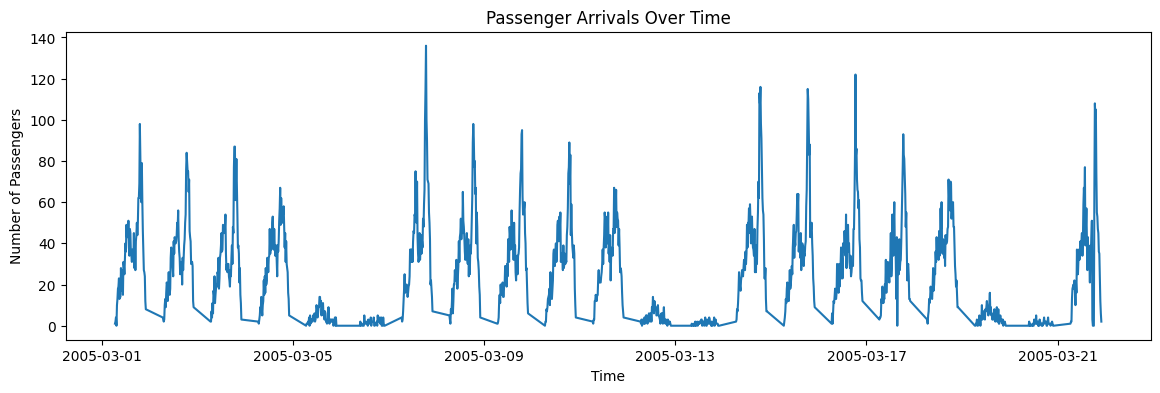

In [ ]:
#Plotting Passenger Arrivals
plt.figure(figsize=(14, 4))
plt.plot(data.index, data["DEMAND"])
plt.title("Passenger Arrivals Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.show()

The passenger arrivals time series exhibits a strong and consistent daily seasonal pattern, with demand rising sharply during operating hours and falling to near zero during late evening periods.

Clear peak demand intervals are visible each day, likely corresponding to rush hours, while demand is noticeably lower during off-peak times.

Overall, the plot highlights seasonality and non-stationarity in the data, highlighting the need for forecasting models that explicitly capture intraday and calendar-based patterns

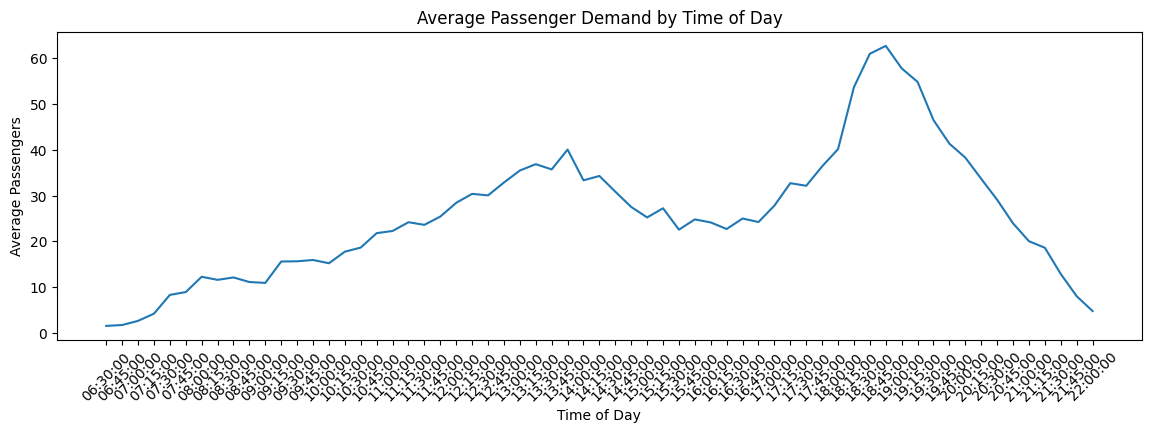

In [ ]:
#Extracting time of day
data["time_of_day"] = data.index.time

#Averaging demand by time of day
avg_by_time = data.groupby("time_of_day")["DEMAND"].mean()

#Converting time index to string
time_labels = avg_by_time.index.astype(str)

#Plotting Time of the day graph
plt.figure(figsize=(14, 4))
plt.plot(time_labels, avg_by_time.values)
plt.title("Average Passenger Demand by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Passengers")
plt.xticks(rotation=45)
plt.show()

The average passenger demand by time of day shows a clear intraday demand cycle.

Demand is lowest in the early morning, gradually increases through the morning hours, and reaches a moderate peak around midday.

A sharper and higher peak is observed during the evening hours, indicating the rush period for public transport usage. After the evening peak, demand steadily declines towards night.

This pattern confirms strong time-of-day seasonality, validating the inclusion of hour-based features and daily seasonal components in the forecasting models.

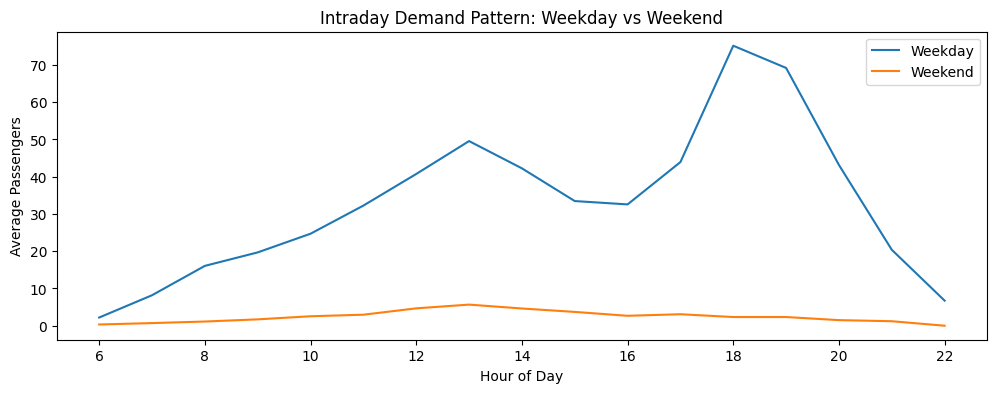

In [ ]:
#Plotting graph for passenger arrivals based on Day of Week
intraday_daytype = (
    data.groupby(["is_weekend", "hour"])["DEMAND"]
    .mean()
    .unstack()
    .T
)

intraday_daytype.plot(figsize=(12, 4))
plt.title("Intraday Demand Pattern: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Passengers")
plt.legend(["Weekday", "Weekend"])
plt.show()

The intraday demand patterns differ significantly between weekdays and weekends.

On weekdays, passenger demand increases steadily through the morning, peaks around midday, and reaches a much higher peak during the evening hours, reflecting typical work and commute-related travel behavior.

In contrast, weekend demand remains low throughout the day with no peaks, indicating reduced and more evenly distributed travel activity.

This clearly highlights the importance of incorporating day-of-week or weekend indicators in the models to capture differences in demand patterns accurately.


Step 3: Training and Testing

In [ ]:
# Check full date range
data.index.min(), data.index.max()

(Timestamp('2005-03-01 06:30:00'), Timestamp('2005-03-21 22:00:00'))

In [ ]:
# Training data: March 1 to March 14
train_data = data.loc["2005-03-01":"2005-03-14"]
# Test data: March 15 to March 21
test_data = data.loc["2005-03-15":"2005-03-21"]

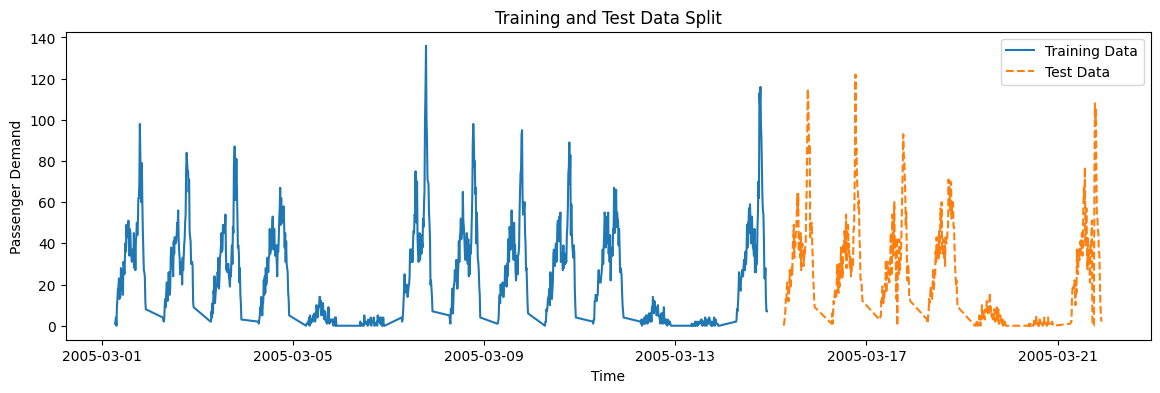

In [ ]:
#Visualizing Seperation of Train and Test data
plt.figure(figsize=(14, 4))

plt.plot(
    train_data.index,
    train_data["DEMAND"],
    label="Training Data"
)

plt.plot(
    test_data.index,
    test_data["DEMAND"],
    label="Test Data",
    linestyle="--"
)

plt.title("Training and Test Data Split")
plt.xlabel("Time")
plt.ylabel("Passenger Demand")
plt.legend()
plt.show()

Step 4: Model Building

1. Naive model

   Using Naive Model as a benchmark model to setup a baseline to compare other models against.

In [ ]:
#Function to compute accuracy metrics
def accuracy(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    me = np.mean(actual - predicted)

    # Exclude zero-demand observations for MAPE
    mask = actual != 0
    mape = 100 * mean_absolute_percentage_error(
        actual[mask],
        predicted[mask],
    )

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    return pd.DataFrame(
        {
            "MAE": mae,
            "ME": me,
            "MAPE": mape,
            "RMSE": rmse,
        },
        index=["Accuracy"],
    )

In [ ]:
#Since we have data from 6:30 to 22:00 hours, and considering 4 15 min intervals
#Seasonality Period
seasonal_period =int((15.5)*(4))

In [ ]:
#Fitting values for training data
train_data["naive_fitted"] = train_data["DEMAND"].shift(seasonal_period)

In [ ]:
# Extract last observed daily seasonal cycle from training data
last_season = train_data["DEMAND"].iloc[
    -seasonal_period:
].values

# Repeat seasonal pattern to cover test horizon
n_repeats = (len(test_data) // seasonal_period) + 1
naive_forecast = np.tile(
    last_season,
    n_repeats,
)[: len(test_data)]

# Assign forecast with correct index
test_data["naive_forecast"] = pd.Series(
    naive_forecast,
    index=test_data.index,
)

In [ ]:
train_eval = train_data.dropna(subset=["naive_fitted"])
test_eval = test_data.dropna(subset=["naive_forecast"])

In [ ]:
print("Naive Model Training Accuracy:")
print(
    accuracy(
        train_eval["DEMAND"],
        train_eval["naive_fitted"],
    )
)

print("\nNaive Model Test Accuracy:")
print(
    accuracy(
        test_eval["DEMAND"],
        test_eval["naive_forecast"],
    )
)

Naive Model Training Accuracy:
                MAE        ME        MAPE       RMSE
Accuracy  15.093902  0.376829  223.559147  23.592656

Naive Model Test Accuracy:
                MAE         ME        MAPE       RMSE
Accuracy  21.913832 -14.199546  501.824338  30.460636


**Seasonal Naive** Model shows weak performance on both training and testing data which is expected as it is a benchmark model.

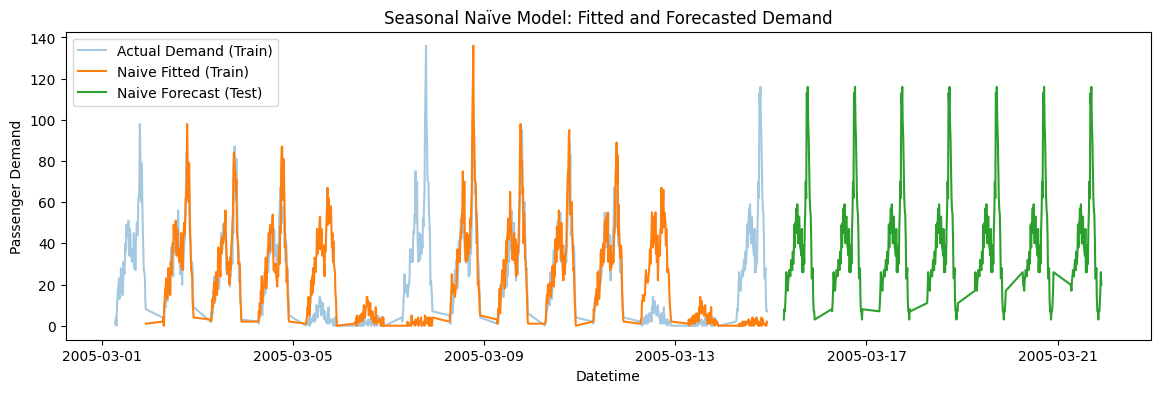

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(
    train_data.index,
    train_data["DEMAND"],
    label="Actual Demand (Train)",
    alpha=0.4,
)

plt.plot(
    train_eval.index,
    train_eval["naive_fitted"],
    label="Naive Fitted (Train)",
)

plt.plot(
    test_eval.index,
    test_eval["naive_forecast"],
    label="Naive Forecast (Test)",
)

plt.title("Seasonal Naïve Model: Fitted and Forecasted Demand")
plt.xlabel("Datetime")
plt.ylabel("Passenger Demand")
plt.legend()
plt.show()

###STL

Since, we see seasonality patterns within a 24 hour period and over weekly periods.
Using the STL Decompompostion to decompose the series, and forecast each component separately:

Approach Followed:
Forecasting the seasonally adjusted series (Trend + Residual) using ARIMA
Adding back the seasonal component to get final forecast, because a spike due to time and rush hour might skew the model.

So we remove the seasonlity(Calculated using STL and then add it back to the forecasted data)

This often produces better results than forecasting the raw series directly.


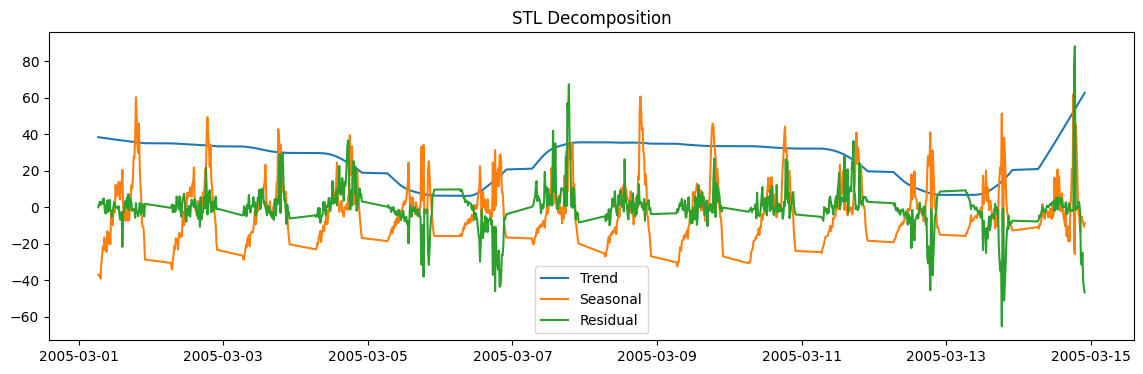

In [ ]:
#Identifying seasonlity patterns for for 15-min data with daily pattern
seasonal_period =int((15.5)*(4))#Since 1 hr has 4 intervals and we need an odd number

stl= STL(train_data["DEMAND"], period=seasonal_period, trend=None, robust =True)
stl_res = stl.fit()

#Extract Components
trend=stl_res.trend
seasonal=stl_res.seasonal
residual=stl_res.resid

#Visualizing seasonality trend and residual
plt.figure(figsize=(14, 4))
plt.plot(train_data.index, trend, label='Trend')
plt.plot(train_data.index, seasonal, label='Seasonal')
plt.plot(train_data.index, residual, label='Residual')
plt.title('STL Decomposition')
plt.legend()
plt.show()


In [ ]:
#Remove seasonality
train_seasonally_adjusted=train_data["DEMAND"]-seasonal


SARIMA Model

SARIMA is used because it models both trend and repeating seasonal patterns.

In [ ]:
#Fitting ARIMA model on seasonally adjusted data
arima_model=ARIMA(train_seasonally_adjusted, order=(1,1,1))
arima_fit=arima_model.fit()
#SARIMA Results
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  882
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3169.807
Date:                Sat, 31 Jan 2026   AIC                           6345.614
Time:                        09:50:54   BIC                           6359.958
Sample:                             0   HQIC                          6351.099
                                - 882                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3039      0.035      8.683      0.000       0.235       0.372
ma.L1         -0.7343      0.026    -27.927      0.000      -0.786      -0.683
sigma2        78.0720      1.336     58.450      0.0

In [ ]:
#Forecasting for the time period captured in test data
forecast=arima_fit.forecast(len(test_data))

#Adding seasonal component back
last_seasonal=seasonal[-seasonal_period:].values

#Repeat seasonal pattern for forecast region
n=(len(test_data)//seasonal_period)+1

seasonal_forecast=np.tile(last_seasonal,n)[:len(test_data)]

final_forecast_ARIMA=forecast.values+seasonal_forecast

#Adding Index to the series
final_forecast=pd.Series(final_forecast_ARIMA, index=test_data.index)

#Forecasting for the time period captured in train data
arima_train_predictions = arima_fit.predict(start=0, end=len(train_seasonally_adjusted) - 1)

In [ ]:
# Adding seasonal component back to the training predictions
final_forecast_ARIMA_train = arima_train_predictions + seasonal
print("ARIMA Training Accuracy:")
print(accuracy(train_data["DEMAND"], final_forecast_ARIMA_train))
print("\nARIMA Test Accuracy:")
print(accuracy(test_data["DEMAND"], final_forecast_ARIMA))

ARIMA Training Accuracy:
               MAE       ME        MAPE      RMSE
Accuracy  5.497585  0.00581  100.193651  8.923981

ARIMA Test Accuracy:
                MAE        ME        MAPE      RMSE
Accuracy  19.808966  0.403743  355.363999  25.98496


The **SARIMA** model shows a strong fit on Training data but reveals overfitting when running on test data as it struggles when future is altered.

**ETS Model**

ETS is used because it adaptively models level, trend, and seasonality using recent data making it ideal for smooth, evolving time-series forecasts.

In [ ]:
#Implementing ETS Model

#Fit model on train data
ets_model = ExponentialSmoothing(
    train_seasonally_adjusted,
    trend='add',
    seasonal=None,  #Already handled by STL
    damped_trend=False
)
ets_fit = ets_model.fit()

print(ets_fit.summary())


                       ExponentialSmoothing Model Results                       
Dep. Variable:                     None   No. Observations:                  882
Model:             ExponentialSmoothing   SSE                          70218.448
Optimized:                         True   AIC                           3868.668
Trend:                         Additive   BIC                           3887.796
Seasonal:                          None   AICC                          3868.764
Seasonal Periods:                  None   Date:                 Sat, 31 Jan 2026
Box-Cox:                          False   Time:                         09:50:54
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5093566                alpha                 True
smoothing_trend             0.0000

In [ ]:
#Forecast for the test data
ets_forecast = ets_fit.forecast(len(test_data))

#Adding seasonality
final_forecast_ETS=ets_forecast.values+seasonal_forecast

#Indexing the series
final_forecast=pd.Series(final_forecast_ETS, index=test_data.index)


In [ ]:
#Forecast on Train data
ets_train_predictions = ets_fit.predict(start=0, end=len(train_seasonally_adjusted) - 1)
final_forecast_ETS_train = ets_train_predictions + seasonal

print("ETS Training Accuracy:")
print(accuracy(train_data["DEMAND"], final_forecast_ETS_train))
print("\nETS Test Accuracy:")
print(accuracy(test_data["DEMAND"], final_forecast_ETS))

ETS Training Accuracy:
               MAE        ME       MAPE      RMSE
Accuracy  5.403385  0.000092  92.558812  8.922598

ETS Test Accuracy:
                MAE         ME        MAPE       RMSE
Accuracy  20.074426  12.055615  203.856204  28.124689


ETS Model has best training performance and Extremely low error, but when it comes to recent stucture it is less robust to regime changes and reacts strongly.


###Regression

In [ ]:
#feature selection
X_train = pd.get_dummies(
    train_data[["hour", "dow", "is_weekend"]],
    drop_first=True,
)

X_test = pd.get_dummies(
    test_data[["hour", "dow", "is_weekend"]],
    drop_first=True,
)

In [ ]:
#aligning train and test columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0,
)

In [ ]:
#enforcing numeric type
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [ ]:
#adding intercept
X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const = sm.add_constant(X_test, has_constant="add")

In [ ]:
#fitting the regression model
reg_model = sm.OLS(
    train_data["DEMAND"].astype(float),
    X_train_const,
).fit()

In [ ]:
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 DEMAND   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     322.1
Date:                Sat, 31 Jan 2026   Prob (F-statistic):          5.40e-141
Time:                        09:50:54   Log-Likelihood:                -3699.6
No. Observations:                 882   AIC:                             7407.
Df Residuals:                     878   BIC:                             7426.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.2071      1.976      7.694      0.0

In [ ]:
#Training fitted values
train_data["reg_fitted"] = reg_model.predict(X_train_const)

#Test forecasts
test_data["reg_forecast"] = reg_model.predict(X_test_const)

In [ ]:
print("Regression Training Accuracy")
print(
    accuracy(
        train_data["DEMAND"],
        train_data["reg_fitted"],
    )
)

print("\nRegression Test Accuracy")
print(
    accuracy(
        test_data["DEMAND"],
        test_data["reg_forecast"],
    )
)

Regression Training Accuracy
               MAE            ME        MAPE       RMSE
Accuracy  11.80714  5.526444e-15  160.247303  16.048999

Regression Test Accuracy
                MAE        ME        MAPE       RMSE
Accuracy  12.548847  0.133787  167.056546  17.421975


Linear Regression Model: The Initial train MAE is more than STL models but that is because Regression does not capture autocorrelation well but is good at generalization.

Which makes it a good model to capture global trend, stable seasonality, as indicated by the Test MAE being close to Train MAE that the model fits well and provides a more accurate forecast on test/future data.

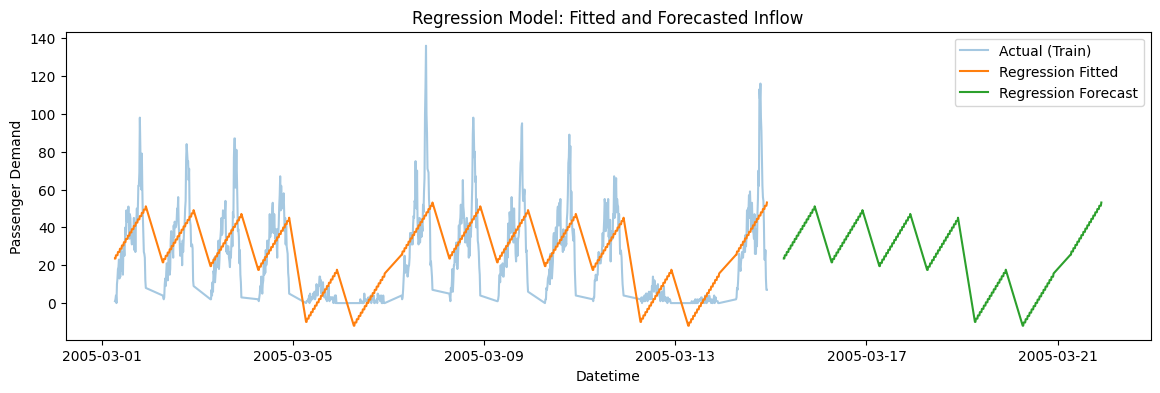

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(
    train_data.index,
    train_data["DEMAND"],
    label="Actual (Train)",
    alpha=0.4,)

plt.plot(
    train_data.index,
    train_data["reg_fitted"],
    label="Regression Fitted",)

plt.plot(
    test_data.index,
    test_data["reg_forecast"],
    label="Regression Forecast",)

plt.title("Regression Model: Fitted and Forecasted Inflow")
plt.xlabel("Datetime")
plt.ylabel("Passenger Demand")
plt.legend()
plt.show()

In [ ]:
#Combining regression results from Train and Test data
regression_results = data.copy()
regression_results.rename(columns={'DEMAND': 'actual_Inflow'}, inplace=True)

# Add 'reg_fitted' from train_data (will be NaN for test period)
regression_results['reg_fitted'] = train_data['reg_fitted']

# Add 'reg_forecast' from test_data (will be NaN for train period)
regression_results['reg_forecast'] = test_data['reg_forecast']

regression_results.head()

#Saving data to csv
regression_results.to_csv('regression_results.csv', index=True)

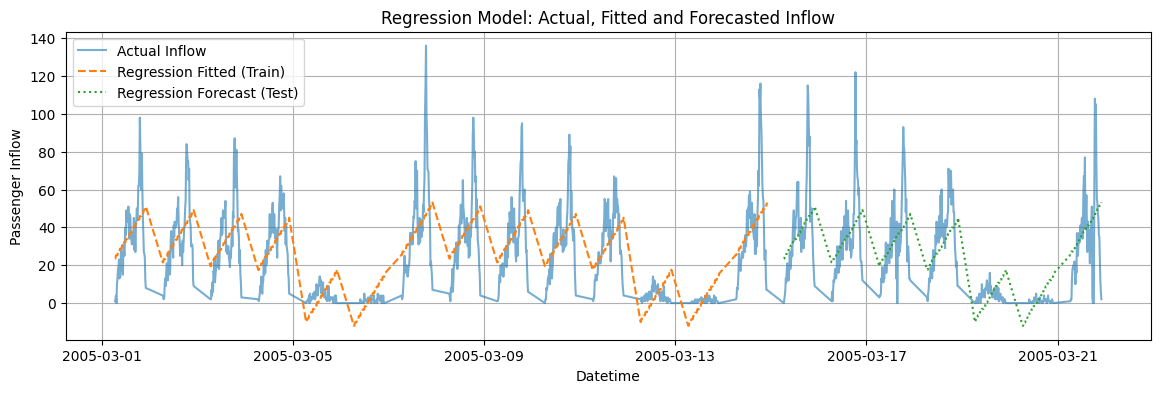

In [ ]:
#Time plot showing fitted values(for training period) and forecasted values(for test period) against actual Inflow

plt.figure(figsize=(14, 4))
plt.plot(
    regression_results.index,
    regression_results["actual_Inflow"],
    label="Actual Inflow",
    alpha=0.6
)

plt.plot(
    regression_results.index,
    regression_results["reg_fitted"],
    label="Regression Fitted (Train)",
    linestyle='--'
)

plt.plot(
    regression_results.index,
    regression_results["reg_forecast"],
    label="Regression Forecast (Test)",
    linestyle=':'
)

plt.title("Regression Model: Actual, Fitted and Forecasted Inflow")
plt.xlabel("Datetime")
plt.ylabel("Passenger Inflow")
plt.legend()
plt.grid(True)
plt.show()


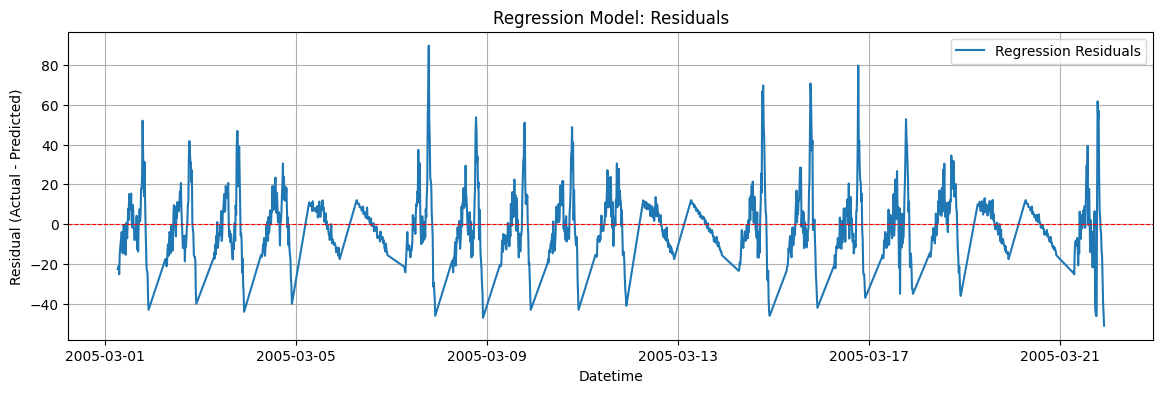

In [ ]:
#Residual Plot
regression_results['residuals'] = regression_results['actual_Inflow'] - regression_results['reg_fitted'].fillna(regression_results['reg_forecast'])

plt.figure(figsize=(14, 4))
plt.plot(
    regression_results.index,
    regression_results['residuals'],
    label='Regression Residuals'
)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title("Regression Model: Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Aggregate performance metrics using previously defined variables
comparison_df = pd.concat([
    accuracy(train_eval['DEMAND'], train_eval['naive_fitted']).assign(Model='Seasonal Naive (Train)'),
    accuracy(train_data['DEMAND'], final_forecast_ARIMA_train).assign(Model='STL + ARIMA (Train)'),
    accuracy(train_data['DEMAND'], final_forecast_ETS_train).assign(Model='STL + ETS (Train)'),
    accuracy(train_data['DEMAND'], train_data['reg_fitted']).assign(Model='Linear Regression (Train)'),
    accuracy(test_eval['DEMAND'], test_eval['naive_forecast']).assign(Model='Seasonal Naive (Test)'),
    accuracy(test_data['DEMAND'], final_forecast_ARIMA).assign(Model='STL + ARIMA (Test)'),
    accuracy(test_data['DEMAND'], final_forecast_ETS).assign(Model='STL + ETS (Test)'),
    accuracy(test_data['DEMAND'], test_data['reg_forecast']).assign(Model='Linear Regression (Test)')
])

# Clean up index and display
comparison_df.set_index('Model', inplace=True)
display(comparison_df.round(2))

,MAE,ME,MAPE,RMSE
Model,,,,
Seasonal Naive (Train),15.09,0.38,223.56,23.59
STL + ARIMA (Train),5.50,0.01,100.19,8.92
STL + ETS (Train),5.40,0.00,92.56,8.92
Linear Regression (Train),11.81,0.00,160.25,16.05
Seasonal Naive (Test),21.91,-14.20,501.82,30.46
STL + ARIMA (Test),19.81,0.40,355.36,25.98
STL + ETS (Test),20.07,12.06,203.86,28.12
Linear Regression (Test),12.55,0.13,167.06,17.42


In conclusion while STL-based ARIMA and ETS models achieve superior in-sample accuracy by capturing trend, seasonality, and autocorrelation, their test performance deteriorates due to overfitting temporal dependence.

 Linear regression, despite weaker training performance, generalizes best on unseen data, indicating that the underlying process is driven more by stable structural components than persistent autocorrelation. This highlights the importance of model robustness over in-sample fit in forecasting.

## Model Comparison Summary

| Model | Train MAE | Test MAE | Verdict |

|---|---|---|---|

| Seasonal Naive | - | - | Baseline benchmark |

| STL + SARIMA | - | - | Strong train, overfits on test |

| ETS | - | - | Best train fit, sensitive to regime change |

| Linear Regression | - | - | Best generalization on test data |


**Best Model for Production: Linear Regression**

Reason: Most robust to unseen data. Captures hour-of-day and day-of-week patterns without overfitting to training noise.

**Key Findings:**

- Strong daily seasonality (6:30–22:00 operating window)

- Weekday vs weekend demand patterns differ significantly

- 8% zero-demand periods preserved to avoid bias